# EDA

In [ ]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, 3e357783-e23c-4851-9daf-783c7a04ead8, 4, Finished, Available, Finished, False)

In [4]:
%run ./tariff_plot

StatementMeta(, 3e357783-e23c-4851-9daf-783c7a04ead8, 6, Finished, Available, Finished, True)

In [5]:
%run ./consumption_plot

StatementMeta(, 3e357783-e23c-4851-9daf-783c7a04ead8, 7, Finished, Available, Finished, True)

In [9]:
%run ./peak_plot

StatementMeta(, 3e357783-e23c-4851-9daf-783c7a04ead8, 11, Finished, Available, Finished, True)

## import existing data

In [ ]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data_v2")
print(month_result.shape)

StatementMeta(, 3e357783-e23c-4851-9daf-783c7a04ead8, 3, Finished, Available, Finished, False)

In [ ]:
# teriff data
tariff_df = (
    spark.read.format("csv")
    .option("header", "true")
    .option("sep", ";")
    .load("abfss://902275ba-e699-4505-9532-1f979686157f@onelake.dfs.fabric.microsoft.com/cd3a1398-1ea6-4b6b-a5c7-68d125bf9ac0/Files/Anläggningar med tidsindelad from 1 dec 2025.csv")
)
tariff_df.createOrReplaceTempView("tariff_df")
# display(tariff_df)
tariff_data = tariff_df.toPandas()

In [ ]:
# hour_result= pd.read_parquet("/lakehouse/default/Files/hour_data")
# print(hour_result.shape)

In [ ]:
# weekday_result= pd.read_parquet("/lakehouse/default/Files/weekday_data")
# print(weekday_result.shape)

## Start EDA - Tariff

StatementMeta(, 85aa2480-4071-45aa-812a-492f5a5e0d8b, 25, Finished, Available, Finished, False)

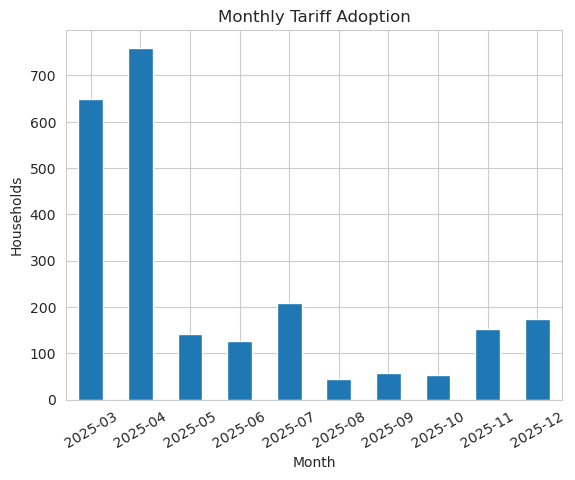

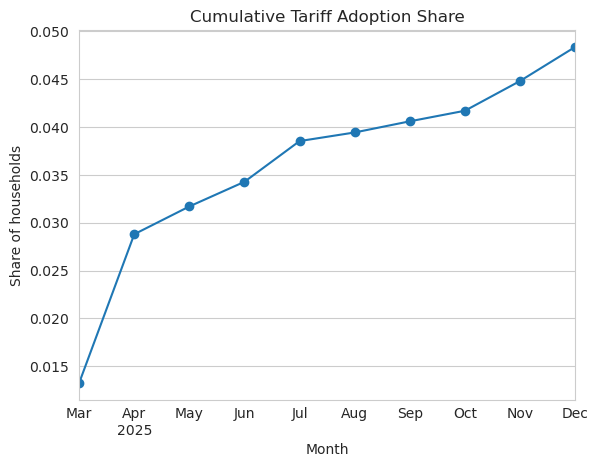

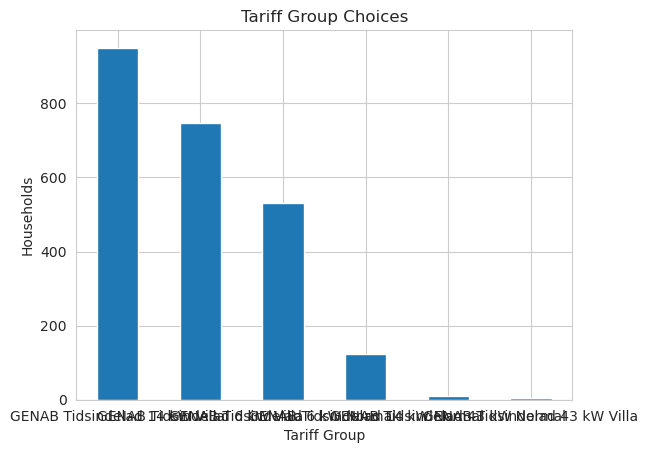

<Figure size 640x480 with 0 Axes>

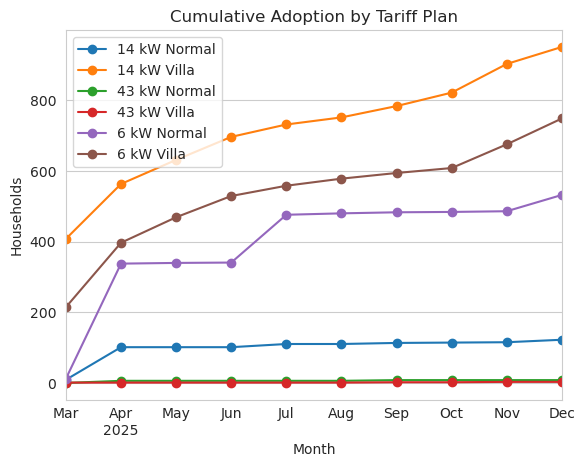

In [24]:
plot_monthly_adoption(tariff_data)
plt.show()

plot_monthly_share(tariff_data, total_households=48930)
plt.show()

plot_tariff_group_counts(tariff_data)
plt.show()

plot_tariff_group_cumulative(tariff_data)
plt.show()

## Electricity data

StatementMeta(, 85aa2480-4071-45aa-812a-492f5a5e0d8b, 26, Finished, Available, Finished, False)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

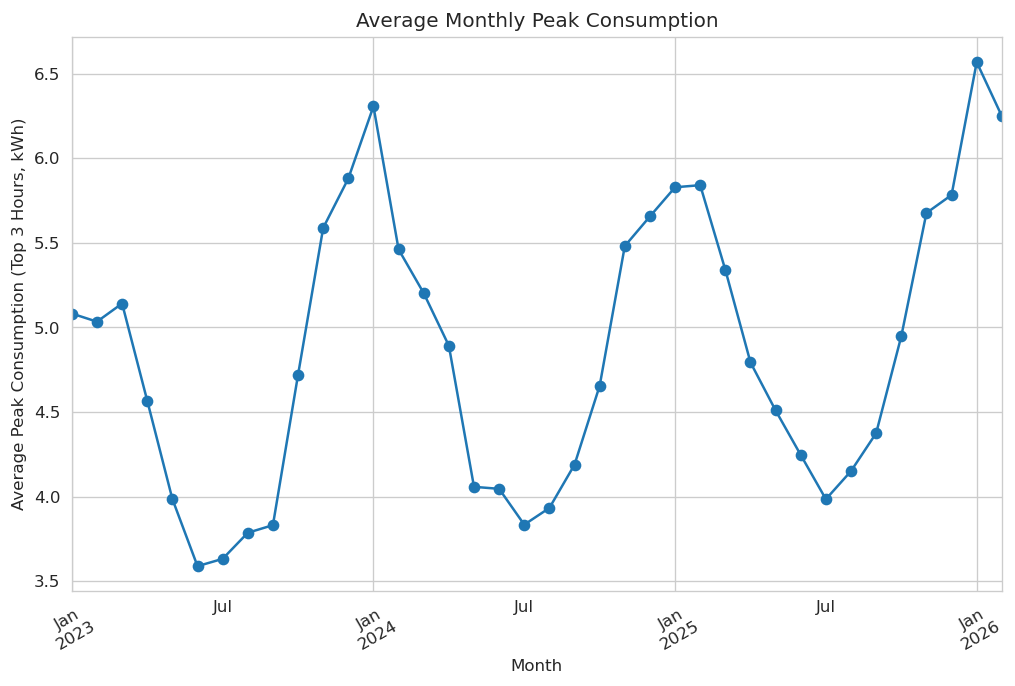

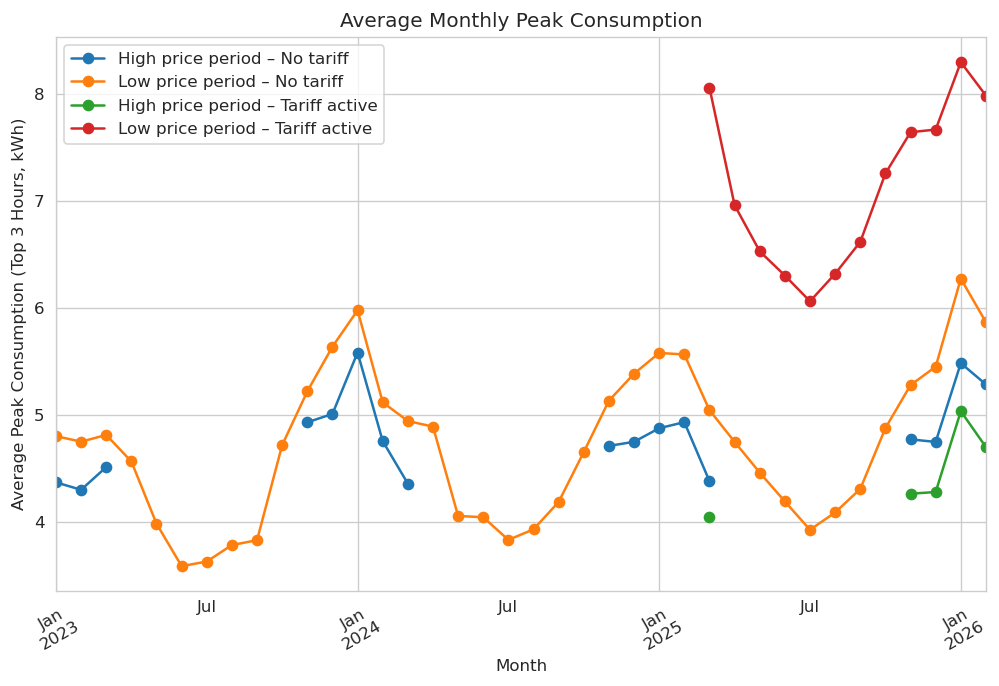

In [ ]:
# month
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    show_legend=False
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"]
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"],
    exclude_future_tariff=True
)

In [ ]:
# hour
plot_consumption(
    hour_result,
    group_by="hour",
    value_col="mean_consumption",
)

hour_result.groupby("tariff_active").size()


# hour
plot_consumption(
    hour_result,
    group_by="hour",
    value_col="mean_consumption",
    splits=["tariff_active"]
)

# hour
plot_consumption(
    hourly_result,
    group_by="hour",
    value_col="mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

StatementMeta(, 85aa2480-4071-45aa-812a-492f5a5e0d8b, 27, Finished, Available, Finished, False)

NameError: name 'hour_result' is not defined

In [ ]:
# weekend, week
plot_consumption(
    weekly_result,
    group_by="weekday",
    value_col="mean_consumption",
)

StatementMeta(, 85aa2480-4071-45aa-812a-492f5a5e0d8b, 28, Finished, Available, Finished, False)

<Axes: title={'center': 'Average Monthly Peak Consumption'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

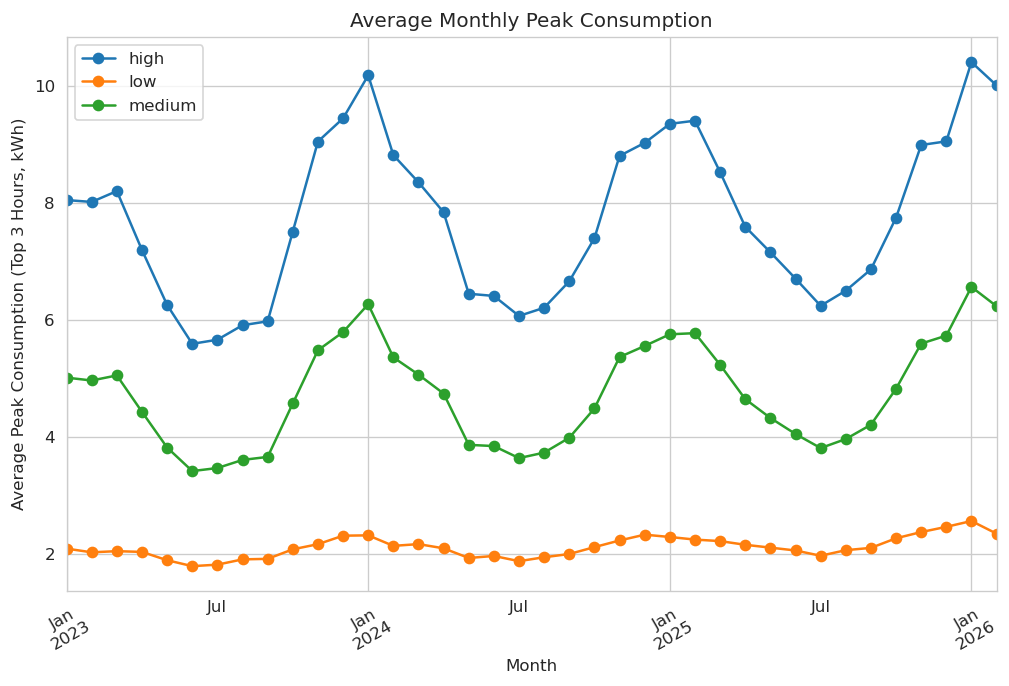

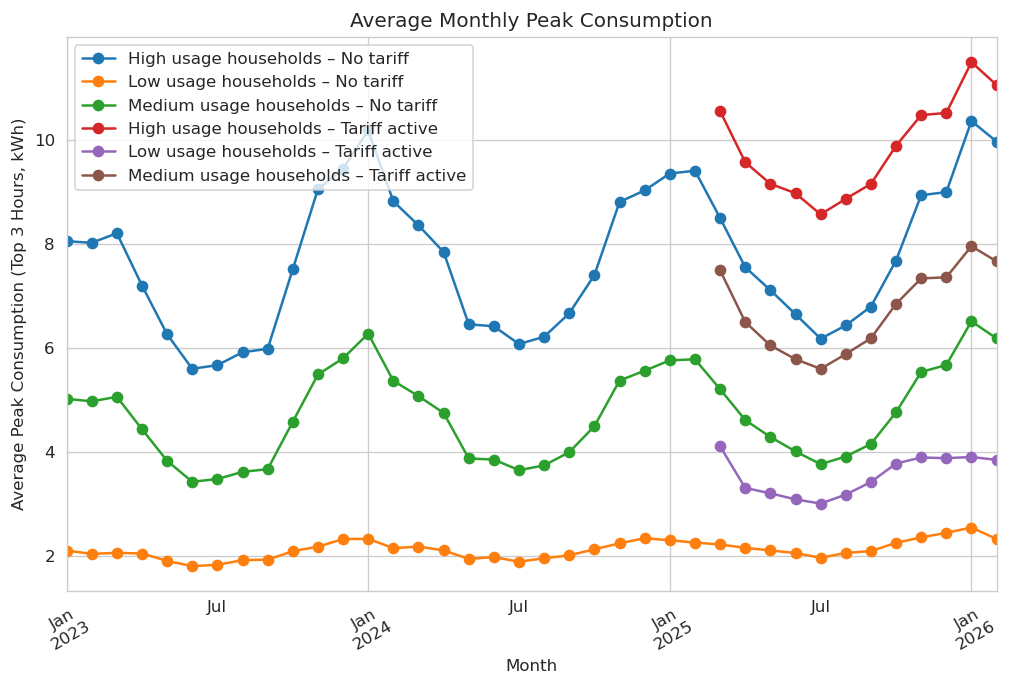

In [ ]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group"]
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    facet_by="usage_group"
)

In [ ]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    exclude_future_tariff=True,
    facet_by="usage_group"
)

StatementMeta(, 85aa2480-4071-45aa-812a-492f5a5e0d8b, 29, Finished, Available, Finished, False)

<Axes: title={'center': 'Tariff Adoption by Household Usage Group'}, xlabel='Household Usage Group', ylabel='Share Choosing Tariff'>

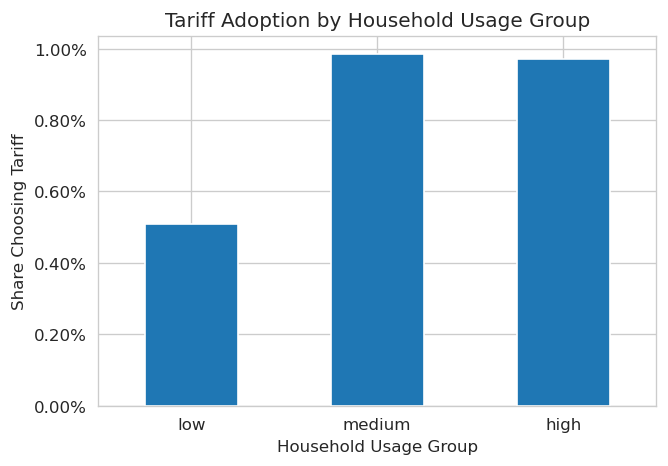

In [ ]:
plot_tariff_adoption_by_usage(
    month_result,
    figsize=(6, 4)
)

StatementMeta(, 85aa2480-4071-45aa-812a-492f5a5e0d8b, 30, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

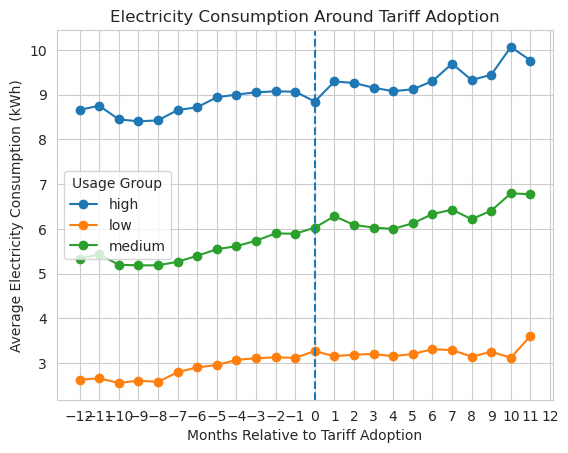

In [ ]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result,
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

In [ ]:
# check
month_result[month_result["tariff_plan"].notna()]

StatementMeta(, 81566eae-030c-4c9a-ad90-16b8b148f53f, 10, Finished, Available, Finished, False)

,aID,TIDPUNKT,price,tariff_active,peak1_time,peak1_consumption,peak2_time,peak2_consumption,peak3_time,peak3_consumption,top3_mean_consumption,variance_consumption,mean_consumption,total_consumption,usage_group,tariff_start,tariff_plan
4185,735999166200434727,2023-03-01,all,0,2023-03-15 17:00:00,5.40000000,2023-03-18 14:00:00,5.23000000,2023-03-30 14:00:00,5.16000000,5.263333,0.580139,2.498588709677,43456.88100000,medium,2025-12-01,6 kW Villa
4186,735999166200434727,2025-08-01,all,0,2025-08-20 20:00:00,3.07900000,2025-08-13 20:00:00,2.93400000,2025-08-01 20:00:00,2.31100000,2.774667,0.230243,0.373091397849,43456.88100000,medium,2025-12-01,6 kW Villa
4187,735999166200434727,2025-07-01,low,0,2025-07-02 16:00:00,2.75500000,2025-07-27 23:00:00,2.55100000,2025-07-30 07:00:00,2.51900000,2.608333,0.197020,0.336220430108,43456.88100000,medium,2025-12-01,6 kW Villa
4188,735999166200434727,2023-01-01,low,0,2023-01-28 17:00:00,6.76000000,2023-01-21 12:00:00,4.66000000,2023-01-22 20:00:00,4.44000000,5.286667,0.457765,2.424140127389,43456.88100000,medium,2025-12-01,6 kW Villa
4189,735999166200434727,2025-06-01,low,0,2025-06-30 07:00:00,4.32900000,2025-06-05 06:00:00,2.44700000,2025-06-12 03:00:00,2.35400000,3.043333,0.359595,0.543888888889,43456.88100000,medium,2025-12-01,6 kW Villa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4537894,735999166300435983,2023-09-01,low,0,2023-09-18 19:00:00,7.39200000,2023-09-25 18:00:00,7.03600000,2023-09-11 18:00:00,5.43000000,6.619333,0.673012,1.168020833333,40252.95800000,medium,2025-11-01,6 kW Villa
4537895,735999166300435983,2024-06-01,low,0,2024-06-10 21:00:00,4.84800000,2024-06-18 04:00:00,4.02700000,2024-06-03 19:00:00,3.84400000,4.239667,0.179806,0.732188888889,40252.95800000,medium,2025-11-01,6 kW Villa
4537896,735999166300435983,2025-06-01,all,0,2025-06-06 15:00:00,6.19200000,2025-06-09 14:00:00,6.12400000,2025-06-17 13:00:00,5.24800000,5.854667,0.552807,0.706731944444,40252.95800000,medium,2025-11-01,6 kW Villa
4537897,735999166300435983,2025-11-01,all,1,2025-11-02 14:00:00,6.14800000,2025-11-22 21:00:00,5.41600000,2025-11-12 22:00:00,5.33900000,5.634333,0.600476,1.633256944444,40252.95800000,medium,2025-11-01,6 kW Villa


StatementMeta(, 81566eae-030c-4c9a-ad90-16b8b148f53f, 9, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

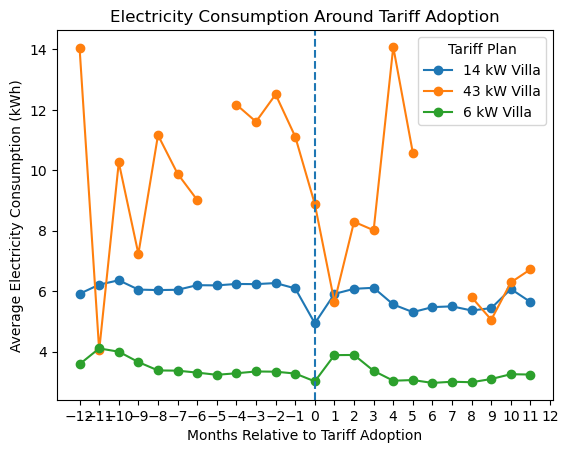

In [ ]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result,
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

In [ ]:
# Peak hour distribution (count)
# 看 peak 最常發生在一天的哪個小時
plot_peak_hour_distribution(month_result[month_result["price"] == "high"])

# Peak hour distribution (consumption)
# 看哪個小時的 peak 用電量總和最高（電網壓力）
plot_peak_hour_distribution(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak heatmap (count)
# Month × Hour heatmap，看不同月份 peak 最常出現的時間
plot_peak_heatmap(month_result[month_result["price"] == "high"])

# Peak heatmap (consumption)
# Month × Hour heatmap，但用顏色表示 peak 用電量
plot_peak_heatmap(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak consumption distribution
# Histogram，看 peak demand 的大小分布（household peak size）
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "high"]
)

# Peak rank boxplot
# 比較 peak1 / peak2 / peak3 的用電量分布，看 spike 程度
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "high"]
)

# Peak timing heatmap: P(hour | peak)
# 比較 tariff 前後 peak 發生次數的 Month × Hour heatmap
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

StatementMeta(, 3e357783-e23c-4851-9daf-783c7a04ead8, 12, Finished, Available, Finished, False)

NameError: name 'plot_peak_hour_distribution' is not defined

In [ ]:
# Overall peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "all"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "all"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "all"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "all"]
)

# Peak timing heatmap: P(hour | peak)
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "all"], 
    price_label="all"
)

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "all"],
    price_label="all"
)


StatementMeta(, e278ba3f-d6b8-4841-b1f0-8dfd76902020, 22, Finished, Available, Finished, False)

In [ ]:
# Low peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "low"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "low"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "low"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "low"]
)

# Peak timing heatmap: P(hour | peak)
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


StatementMeta(, e278ba3f-d6b8-4841-b1f0-8dfd76902020, 23, Finished, Available, Finished, False)